# Evaluation 07: Recommendation Similarity Analysis

## Research Question
**How similar are the recommendations to each other for a given input image?**

### Hypothesis
For a single input image, the 10 recommendations should be reasonably diverse. If recommendations are too similar to each other, it suggests the system may be over-focused on a narrow set of features. If they're too diverse, it may indicate the system isn't finding coherent recommendations.

### Analysis Goals
1. Measure pairwise similarity between recommendations for each query
2. Analyze diversity in color, category, and style
3. Understand the distribution of recommendation similarities
4. Identify patterns in recommendation clustering


## 1. Setup and Imports


In [1]:
# Install required packages
!python3 -m pip install --quiet numpy pandas scikit-learn faiss-cpu matplotlib seaborn scipy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from typing import List, Dict, Tuple
from sklearn.metrics.pairwise import cosine_similarity
import random
import faiss

# Add recommender_system directory to path
notebook_dir = Path.cwd()
if notebook_dir.name == 'evaluation_notebooks':
    recommender_system_dir = notebook_dir.parent
else:
    if (notebook_dir / 'recommender_system').exists():
        recommender_system_dir = notebook_dir / 'recommender_system'
    elif (notebook_dir.parent / 'recommender_system').exists():
        recommender_system_dir = notebook_dir.parent / 'recommender_system'
    else:
        recommender_system_dir = notebook_dir.parent

sys.path.insert(0, str(recommender_system_dir))

from evaluation_utils import (
    load_vectors_and_metadata,
    compute_diversity_score,
    save_plot,
    save_metrics
)
from path_utils import get_faiss_index_dir

# Set style
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Set random seed
random.seed(42)
np.random.seed(42)


## 2. Load Data and FAISS Index


In [3]:
# Load vectors, metadata, and FAISS index
vectors, metadata, product_ids = load_vectors_and_metadata()

print(f"Loaded {len(vectors)} vectors")
print(f"Metadata shape: {metadata.shape}")
print(f"Metadata columns: {list(metadata.columns)}")

# Load FAISS index for similarity search
faiss_index_dir = get_faiss_index_dir()
index_path = faiss_index_dir / "product_index.faiss"
ids_path = faiss_index_dir / "product_ids.pkl"

if index_path.exists():
    print(f"\nLoading FAISS index from: {index_path}")
    faiss_index = faiss.read_index(str(index_path))
    print(f"✓ FAISS index loaded with {faiss_index.ntotal} vectors")
else:
    print(f"\n⚠ FAISS index not found at {index_path}")
    print("Will use loaded vectors directly for similarity search")
    faiss_index = None


Loading vectors and metadata...
Loading vectors from: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_features_pca512.npy
Loaded 41801 vectors of dimension 512
Loading metadata from: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
Loaded 41801 metadata records
Loaded 41801 vectors
Metadata shape: (41801, 10)
Metadata columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

Loading FAISS index from: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/faiss_index/product_index.faiss
✓ FAISS index loaded with 41801 vectors


In [4]:
# Helper function to get recommendations using FAISS index
def get_recommendations_faiss(query_vector: np.ndarray, top_k: int = 10) -> Tuple[np.ndarray, np.ndarray]:
    """
    Get recommendations using FAISS index.
    
    Args:
        query_vector: Query vector of shape (1, dimension) or (dimension,)
        top_k: Number of recommendations
        
    Returns:
        Tuple of (distances, indices)
    """
    if faiss_index is None:
        # Fallback to direct vector similarity if FAISS not available
        query_vector = query_vector.reshape(1, -1).astype('float32')
        similarities = cosine_similarity(query_vector, vectors)
        top_indices = np.argsort(similarities[0])[-top_k:][::-1]
        top_distances = 1 - similarities[0][top_indices]  # Convert similarity to distance
        return top_distances, top_indices
    
    # Use FAISS for efficient search
    query_vector = query_vector.reshape(1, -1).astype('float32')
    distances, indices = faiss_index.search(query_vector, top_k)
    return distances[0], indices[0]


## 3. Helper Functions


In [5]:
def compute_pairwise_similarities(recommendation_vectors: np.ndarray) -> np.ndarray:
    """
    Compute pairwise cosine similarities between recommendations.
    
    Args:
        recommendation_vectors: Array of shape (n_recommendations, feature_dim)
        
    Returns:
        Upper triangular similarity matrix (flattened)
    """
    if len(recommendation_vectors) < 2:
        return np.array([])
    
    # Compute cosine similarity matrix
    similarity_matrix = cosine_similarity(recommendation_vectors)
    
    # Get upper triangular (excluding diagonal)
    n = len(similarity_matrix)
    upper_tri_indices = np.triu_indices(n, k=1)
    pairwise_similarities = similarity_matrix[upper_tri_indices]
    
    return pairwise_similarities


def analyze_recommendation_similarity(
    recommendations_df: pd.DataFrame,
    vectors: np.ndarray,
    metadata: pd.DataFrame,
    product_ids: List[str]
) -> Dict:
    """
    Analyze similarity between recommendations.
    
    Args:
        recommendations_df: DataFrame with recommendations (must have 'id' column)
        vectors: Full feature vector matrix
        metadata: Full metadata DataFrame
        product_ids: List of product IDs aligned with vectors
        
    Returns:
        Dictionary with similarity metrics
    """
    if len(recommendations_df) < 2:
        return {
            'mean_pairwise_similarity': 0.0,
            'std_pairwise_similarity': 0.0,
            'min_pairwise_similarity': 0.0,
            'max_pairwise_similarity': 0.0,
            'color_diversity': 0.0,
            'category_diversity': 0.0,
            'n_recommendations': len(recommendations_df)
        }
    
    # Get indices of recommended products
    rec_ids = recommendations_df['id'].astype(str).tolist()
    rec_indices = [product_ids.index(pid) for pid in rec_ids if pid in product_ids]
    
    if len(rec_indices) < 2:
        return {
            'mean_pairwise_similarity': 0.0,
            'std_pairwise_similarity': 0.0,
            'min_pairwise_similarity': 0.0,
            'max_pairwise_similarity': 0.0,
            'color_diversity': 0.0,
            'category_diversity': 0.0,
            'n_recommendations': len(recommendations_df)
        }
    
    # Get feature vectors for recommendations
    rec_vectors = vectors[rec_indices]
    
    # Compute pairwise similarities
    pairwise_sims = compute_pairwise_similarities(rec_vectors)
    
    # Compute diversity metrics
    color_diversity = compute_diversity_score(recommendations_df['baseColour'])
    category_diversity = compute_diversity_score(recommendations_df['articleType'])
    
    return {
        'mean_pairwise_similarity': float(np.mean(pairwise_sims)),
        'std_pairwise_similarity': float(np.std(pairwise_sims)),
        'min_pairwise_similarity': float(np.min(pairwise_sims)),
        'max_pairwise_similarity': float(np.max(pairwise_sims)),
        'color_diversity': color_diversity,
        'category_diversity': category_diversity,
        'n_recommendations': len(recommendations_df),
        'pairwise_similarities': pairwise_sims.tolist()
    }


In [6]:
# Select 50 random images from the dataset
n_samples = 50
random_indices = random.sample(range(len(metadata)), n_samples)
random_metadata = metadata.iloc[random_indices].reset_index(drop=True)

print(f"Selected {len(random_metadata)} random images")
print(f"\nSample distribution:")
print(f"Categories: {random_metadata['articleType'].value_counts().head(10)}")
print(f"\nColors: {random_metadata['baseColour'].value_counts().head(10)}")

# Store selected indices for later use
selected_indices = random_indices


Selected 50 random images

Sample distribution:
Categories: articleType
Casual Shoes    8
Tshirts         7
Watches         5
Heels           4
Belts           3
Sports Shoes    3
Kurtas          3
Socks           2
Duffel Bag      2
Tops            2
Name: count, dtype: int64

Colors: baseColour
Black        17
Brown         7
Green         4
Blue          4
Navy Blue     3
White         3
Grey          2
Red           2
Purple        2
Teal          1
Name: count, dtype: int64


In [7]:
# Get recommendations for each of the 50 random products using FAISS
all_recommendations = []
all_similarity_analyses = []
failed_queries = []

print("Getting recommendations for 50 random products using FAISS...")
print("This should be fast...\n")

for idx, (row_idx, row) in enumerate(random_metadata.iterrows()):
    product_id = str(row['id'])
    
    try:
        # Find the index of this product in the vectors
        if product_id not in product_ids:
            print(f"  [{idx+1}/50] Product {product_id}: Not found in product_ids, skipping...")
            failed_queries.append({
                'product_id': product_id,
                'reason': 'not_in_product_ids'
            })
            continue
        
        product_idx = product_ids.index(product_id)
        query_vector = vectors[product_idx]
        
        print(f"  [{idx+1}/50] Processing product {product_id}...", end=' ')
        
        # Get recommendations using FAISS (top_k+1 to exclude the query itself)
        distances, indices = get_recommendations_faiss(query_vector, top_k=11)
        
        # Exclude the query product itself (should be the first result)
        if len(indices) > 0 and indices[0] == product_idx:
            indices = indices[1:]
            distances = distances[1:]
        
        # Take top 10 recommendations
        indices = indices[:10]
        distances = distances[:10]
        
        if len(indices) == 0:
            print("No recommendations found")
            failed_queries.append({
                'product_id': product_id,
                'reason': 'no_recommendations'
            })
            continue
        
        # Create recommendations DataFrame
        rec_product_ids = [product_ids[i] for i in indices]
        rec_metadata = metadata[metadata['id'].astype(str).isin(rec_product_ids)].copy()
        
        # Add similarity scores
        rec_metadata['similarity_score'] = 1 - distances  # Convert distance to similarity
        
        # Sort by similarity
        rec_metadata = rec_metadata.sort_values('similarity_score', ascending=False).reset_index(drop=True)
        
        print(f"Got {len(rec_metadata)} recommendations")
        
        # Add query information
        rec_metadata['query_id'] = product_id
        rec_metadata['query_index'] = idx
        rec_metadata['query_articleType'] = row['articleType']
        rec_metadata['query_baseColour'] = row['baseColour']
        
        all_recommendations.append(rec_metadata)
        
        # Analyze similarity between recommendations
        similarity_analysis = analyze_recommendation_similarity(
            rec_metadata,
            vectors,
            metadata,
            product_ids
        )
        similarity_analysis['query_id'] = product_id
        similarity_analysis['query_index'] = idx
        similarity_analysis['query_articleType'] = row['articleType']
        similarity_analysis['query_baseColour'] = row['baseColour']
        
        all_similarity_analyses.append(similarity_analysis)
        
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        failed_queries.append({
            'product_id': product_id,
            'reason': f'error: {str(e)}'
        })
        continue

print(f"\n✓ Completed: {len(all_recommendations)} successful queries")
print(f"  Failed: {len(failed_queries)} queries")

if failed_queries:
    print(f"\nFailed queries: {failed_queries[:5]}...")  # Show first 5


Getting recommendations for 50 random products using FAISS...
This should be fast...

  [1/50] Processing product 11491... Got 10 recommendations
  [2/50] Processing product 55632... Got 10 recommendations
  [3/50] Processing product 47989... Got 10 recommendations
  [4/50] Processing product 36388... Got 10 recommendations
  [5/50] Processing product 34930... Got 10 recommendations
  [6/50] Processing product 9119... Got 10 recommendations
  [7/50] Processing product 7828... Got 10 recommendations
  [8/50] Processing product 49505... Got 10 recommendations
  [9/50] Processing product 19238... Got 10 recommendations
  [10/50] Processing product 3578... Got 10 recommendations
  [11/50] Processing product 30321... Got 10 recommendations
  [12/50] Processing product 30869... Got 10 recommendations
  [13/50] Processing product 25325... Got 10 recommendations
  [14/50] Processing product 12612... Got 10 recommendations
  [15/50] Processing product 39678... Got 10 recommendations
  [16/50] P

## 6. Combine Results and Create Analysis DataFrame


In [8]:
# Combine all recommendations
if all_recommendations:
    combined_recommendations = pd.concat(all_recommendations, ignore_index=True)
    print(f"Total recommendations collected: {len(combined_recommendations)}")
    print(f"Unique queries: {combined_recommendations['query_id'].nunique()}")
else:
    combined_recommendations = pd.DataFrame()
    print("No recommendations collected!")

# Create similarity analysis DataFrame
similarity_df = pd.DataFrame(all_similarity_analyses)

if len(similarity_df) > 0:
    print(f"\nSimilarity analysis for {len(similarity_df)} queries:")
    print(similarity_df[['query_id', 'mean_pairwise_similarity', 'color_diversity', 'category_diversity']].head(10))
else:
    print("\nNo similarity analyses collected!")


Total recommendations collected: 500
Unique queries: 50

Similarity analysis for 50 queries:
  query_id  mean_pairwise_similarity  color_diversity  category_diversity
0    11491                  0.706928              0.2                 0.1
1    55632                  0.680892              0.3                 0.4
2    47989                  0.787538              0.2                 0.1
3    36388                  0.882271              0.5                 0.1
4    34930                  0.662695              0.8                 0.1
5     9119                  0.771818              0.4                 0.1
6     7828                  0.728777              0.1                 0.6
7    49505                  0.791264              0.2                 0.1
8    19238                  0.773659              0.4                 0.3
9     3578                  0.723432              0.3                 0.3


## 7. Summary Statistics


In [9]:
if len(similarity_df) > 0:
    print("=" * 70)
    print("SUMMARY STATISTICS: Recommendation Similarity Analysis")
    print("=" * 70)
    
    print(f"\n1. Pairwise Similarity Metrics:")
    print(f"   Mean pairwise similarity: {similarity_df['mean_pairwise_similarity'].mean():.4f}")
    print(f"   Std pairwise similarity: {similarity_df['mean_pairwise_similarity'].std():.4f}")
    print(f"   Min pairwise similarity: {similarity_df['mean_pairwise_similarity'].min():.4f}")
    print(f"   Max pairwise similarity: {similarity_df['mean_pairwise_similarity'].max():.4f}")
    print(f"   Median pairwise similarity: {similarity_df['mean_pairwise_similarity'].median():.4f}")
    
    print(f"\n2. Diversity Metrics:")
    print(f"   Mean color diversity: {similarity_df['color_diversity'].mean():.4f}")
    print(f"   Mean category diversity: {similarity_df['category_diversity'].mean():.4f}")
    
    print(f"\n3. Distribution:")
    print(f"   Queries with similarity > 0.8: {(similarity_df['mean_pairwise_similarity'] > 0.8).sum()} ({(similarity_df['mean_pairwise_similarity'] > 0.8).mean()*100:.1f}%)")
    print(f"   Queries with similarity > 0.6: {(similarity_df['mean_pairwise_similarity'] > 0.6).sum()} ({(similarity_df['mean_pairwise_similarity'] > 0.6).mean()*100:.1f}%)")
    print(f"   Queries with similarity < 0.4: {(similarity_df['mean_pairwise_similarity'] < 0.4).sum()} ({(similarity_df['mean_pairwise_similarity'] < 0.4).mean()*100:.1f}%)")
    
    print(f"\n4. Recommendations per Query:")
    print(f"   Mean: {similarity_df['n_recommendations'].mean():.2f}")
    print(f"   Min: {similarity_df['n_recommendations'].min()}")
    print(f"   Max: {similarity_df['n_recommendations'].max()}")
    
    print("=" * 70)
else:
    print("No data available for summary statistics")


SUMMARY STATISTICS: Recommendation Similarity Analysis

1. Pairwise Similarity Metrics:
   Mean pairwise similarity: 0.7681
   Std pairwise similarity: 0.0809
   Min pairwise similarity: 0.5513
   Max pairwise similarity: 0.9114
   Median pairwise similarity: 0.7727

2. Diversity Metrics:
   Mean color diversity: 0.4100
   Mean category diversity: 0.1840

3. Distribution:
   Queries with similarity > 0.8: 16 (32.0%)
   Queries with similarity > 0.6: 49 (98.0%)
   Queries with similarity < 0.4: 0 (0.0%)

4. Recommendations per Query:
   Mean: 10.00
   Min: 10
   Max: 10


## 8. Visualizations


Saved plot: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/recommendation_similarity_analysis.png


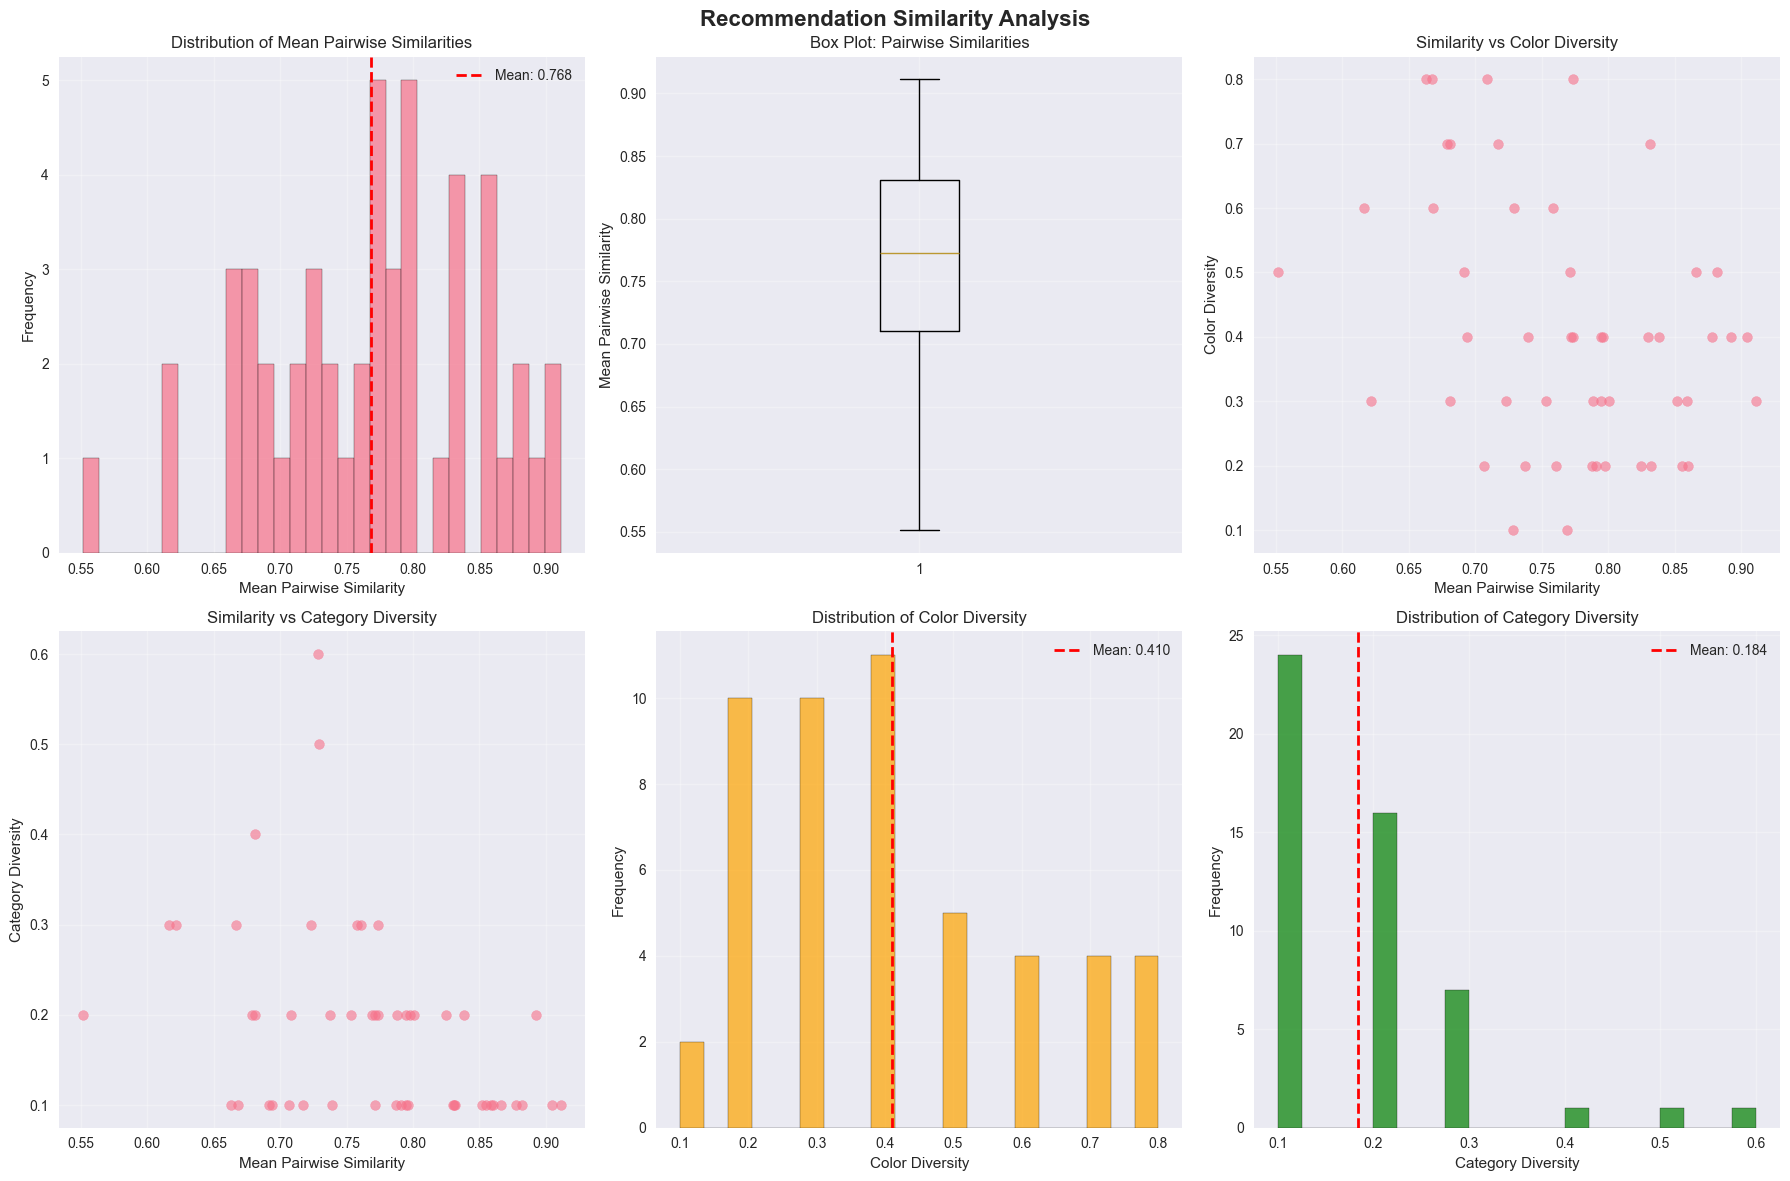

In [10]:
if len(similarity_df) > 0:
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Recommendation Similarity Analysis', fontsize=16, fontweight='bold')
    
    # 1. Distribution of mean pairwise similarities
    ax1 = axes[0, 0]
    ax1.hist(similarity_df['mean_pairwise_similarity'], bins=30, edgecolor='black', alpha=0.7)
    ax1.axvline(similarity_df['mean_pairwise_similarity'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {similarity_df["mean_pairwise_similarity"].mean():.3f}')
    ax1.set_xlabel('Mean Pairwise Similarity')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Mean Pairwise Similarities')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Box plot of similarities
    ax2 = axes[0, 1]
    ax2.boxplot(similarity_df['mean_pairwise_similarity'], vert=True)
    ax2.set_ylabel('Mean Pairwise Similarity')
    ax2.set_title('Box Plot: Pairwise Similarities')
    ax2.grid(True, alpha=0.3)
    
    # 3. Scatter: Similarity vs Color Diversity
    ax3 = axes[0, 2]
    scatter = ax3.scatter(similarity_df['mean_pairwise_similarity'], 
                          similarity_df['color_diversity'],
                          alpha=0.6, s=50)
    ax3.set_xlabel('Mean Pairwise Similarity')
    ax3.set_ylabel('Color Diversity')
    ax3.set_title('Similarity vs Color Diversity')
    ax3.grid(True, alpha=0.3)
    
    # 4. Scatter: Similarity vs Category Diversity
    ax4 = axes[1, 0]
    ax4.scatter(similarity_df['mean_pairwise_similarity'], 
                similarity_df['category_diversity'],
                alpha=0.6, s=50)
    ax4.set_xlabel('Mean Pairwise Similarity')
    ax4.set_ylabel('Category Diversity')
    ax4.set_title('Similarity vs Category Diversity')
    ax4.grid(True, alpha=0.3)
    
    # 5. Distribution of color diversity
    ax5 = axes[1, 1]
    ax5.hist(similarity_df['color_diversity'], bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax5.axvline(similarity_df['color_diversity'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {similarity_df["color_diversity"].mean():.3f}')
    ax5.set_xlabel('Color Diversity')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Distribution of Color Diversity')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Distribution of category diversity
    ax6 = axes[1, 2]
    ax6.hist(similarity_df['category_diversity'], bins=20, edgecolor='black', alpha=0.7, color='green')
    ax6.axvline(similarity_df['category_diversity'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {similarity_df["category_diversity"].mean():.3f}')
    ax6.set_xlabel('Category Diversity')
    ax6.set_ylabel('Frequency')
    ax6.set_title('Distribution of Category Diversity')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_plot(fig, 'recommendation_similarity_analysis.png')
    plt.show()
else:
    print("No data available for visualizations")


## 9. Detailed Pairwise Similarity Analysis


PAIRWISE SIMILARITY STATISTICS (All Recommendation Pairs)
Total pairs analyzed: 2250
Mean similarity: 0.7681
Std similarity: 0.1000
Min similarity: 0.3022
Max similarity: 1.0000
Median similarity: 0.7788
25th percentile: 0.7066
75th percentile: 0.8422
Saved plot: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/pairwise_similarity_distribution.png


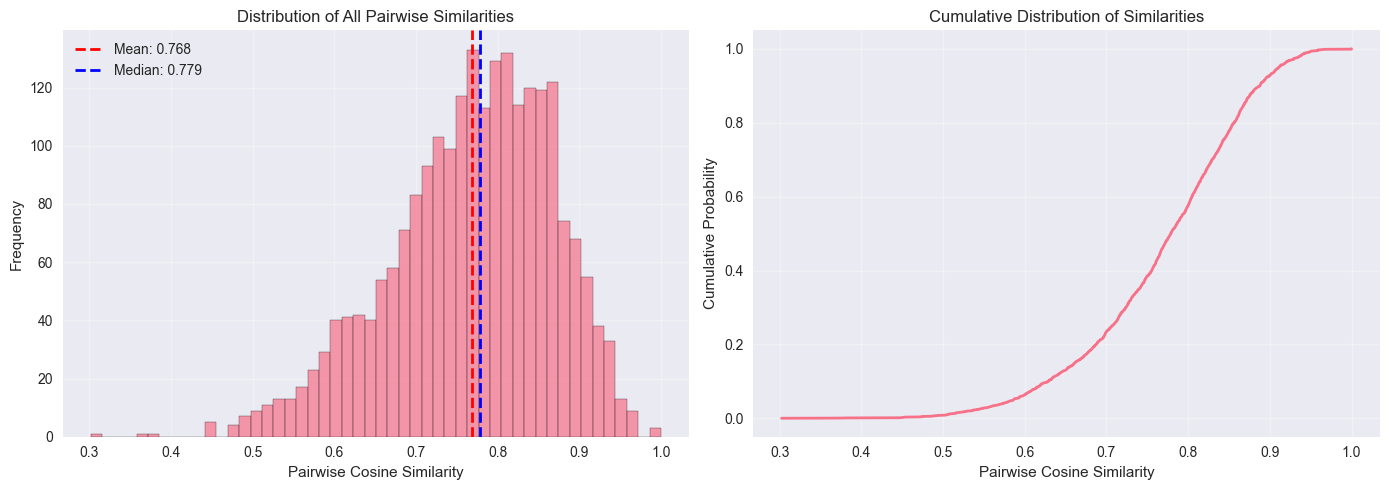

In [11]:
# Collect all pairwise similarities
all_pairwise_sims = []
for analysis in all_similarity_analyses:
    if 'pairwise_similarities' in analysis and len(analysis['pairwise_similarities']) > 0:
        all_pairwise_sims.extend(analysis['pairwise_similarities'])

if len(all_pairwise_sims) > 0:
    all_pairwise_sims = np.array(all_pairwise_sims)
    
    print("=" * 70)
    print("PAIRWISE SIMILARITY STATISTICS (All Recommendation Pairs)")
    print("=" * 70)
    print(f"Total pairs analyzed: {len(all_pairwise_sims)}")
    print(f"Mean similarity: {all_pairwise_sims.mean():.4f}")
    print(f"Std similarity: {all_pairwise_sims.std():.4f}")
    print(f"Min similarity: {all_pairwise_sims.min():.4f}")
    print(f"Max similarity: {all_pairwise_sims.max():.4f}")
    print(f"Median similarity: {np.median(all_pairwise_sims):.4f}")
    print(f"25th percentile: {np.percentile(all_pairwise_sims, 25):.4f}")
    print(f"75th percentile: {np.percentile(all_pairwise_sims, 75):.4f}")
    
    # Create histogram
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    ax1 = axes[0]
    ax1.hist(all_pairwise_sims, bins=50, edgecolor='black', alpha=0.7)
    ax1.axvline(all_pairwise_sims.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {all_pairwise_sims.mean():.3f}')
    ax1.axvline(np.median(all_pairwise_sims), color='blue', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(all_pairwise_sims):.3f}')
    ax1.set_xlabel('Pairwise Cosine Similarity')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of All Pairwise Similarities')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Cumulative distribution
    ax2 = axes[1]
    sorted_sims = np.sort(all_pairwise_sims)
    cumulative = np.arange(1, len(sorted_sims) + 1) / len(sorted_sims)
    ax2.plot(sorted_sims, cumulative, linewidth=2)
    ax2.set_xlabel('Pairwise Cosine Similarity')
    ax2.set_ylabel('Cumulative Probability')
    ax2.set_title('Cumulative Distribution of Similarities')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_plot(fig, 'pairwise_similarity_distribution.png')
    plt.show()
else:
    print("No pairwise similarity data available")


SIMILARITY ANALYSIS BY QUERY CATEGORY
                   mean_pairwise_similarity_mean  \
query_articleType                                  
Shirts                                    0.9047   
Track Pants                               0.8926   
Belts                                     0.8492   
Tshirts                                   0.8406   
Tops                                      0.8195   
Socks                                     0.8109   
Innerwear Vests                           0.7884   
Watches                                   0.7846   
Sports Shoes                              0.7832   
Sandals                                   0.7610   
Stoles                                    0.7582   
Casual Shoes                              0.7539   
Nightdress                                0.7291   
Sports Sandals                            0.7234   
Kurtas                                    0.7203   

                   mean_pairwise_similarity_std  \
query_articleType         

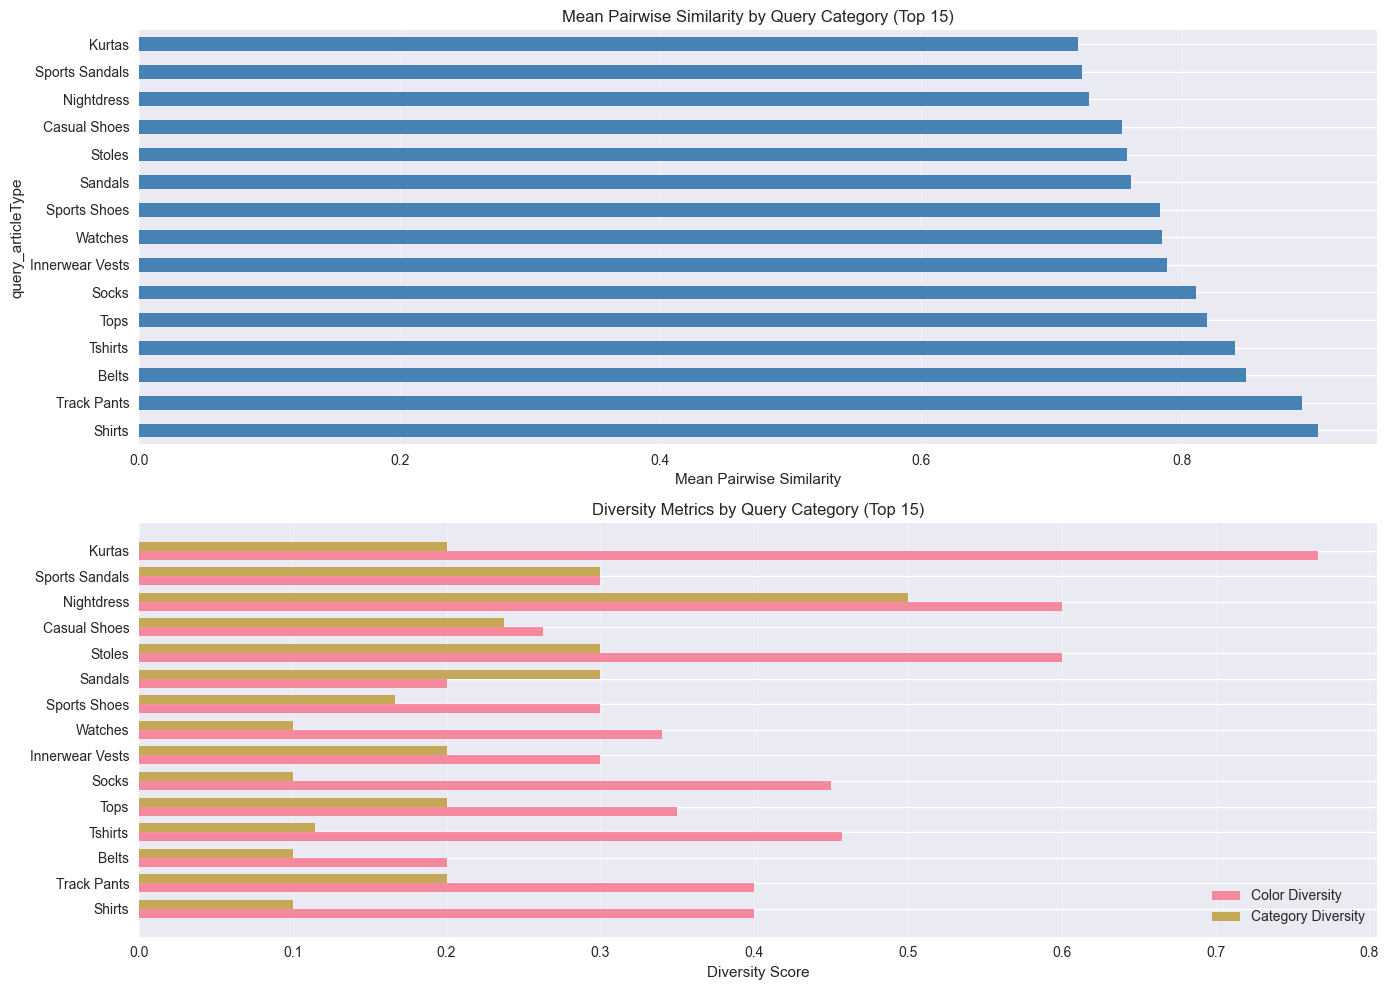

In [12]:
if len(similarity_df) > 0 and 'query_articleType' in similarity_df.columns:
    # Group by query article type
    category_stats = similarity_df.groupby('query_articleType').agg({
        'mean_pairwise_similarity': ['mean', 'std', 'count'],
        'color_diversity': 'mean',
        'category_diversity': 'mean'
    }).round(4)
    
    category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns.values]
    category_stats = category_stats.sort_values('mean_pairwise_similarity_mean', ascending=False)
    
    print("=" * 70)
    print("SIMILARITY ANALYSIS BY QUERY CATEGORY")
    print("=" * 70)
    print(category_stats.head(15))
    
    # Visualization
    if len(category_stats) > 0:
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Top categories by similarity
        top_categories = category_stats.head(15)
        
        # Bar plot: Mean similarity by category
        ax1 = axes[0]
        top_categories['mean_pairwise_similarity_mean'].plot(kind='barh', ax=ax1, color='steelblue')
        ax1.set_xlabel('Mean Pairwise Similarity')
        ax1.set_title('Mean Pairwise Similarity by Query Category (Top 15)')
        ax1.grid(True, alpha=0.3, axis='x')
        
        # Bar plot: Diversity by category
        ax2 = axes[1]
        x = np.arange(len(top_categories))
        width = 0.35
        ax2.barh(x - width/2, top_categories['color_diversity_mean'], width, 
                label='Color Diversity', alpha=0.8)
        ax2.barh(x + width/2, top_categories['category_diversity_mean'], width, 
                label='Category Diversity', alpha=0.8)
        ax2.set_yticks(x)
        ax2.set_yticklabels(top_categories.index)
        ax2.set_xlabel('Diversity Score')
        ax2.set_title('Diversity Metrics by Query Category (Top 15)')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        save_plot(fig, 'similarity_by_category.png')
        plt.show()
else:
    print("No category data available")


## 11. Heatmap: Similarity vs Diversity


Saved plot: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/similarity_diversity_heatmap.png


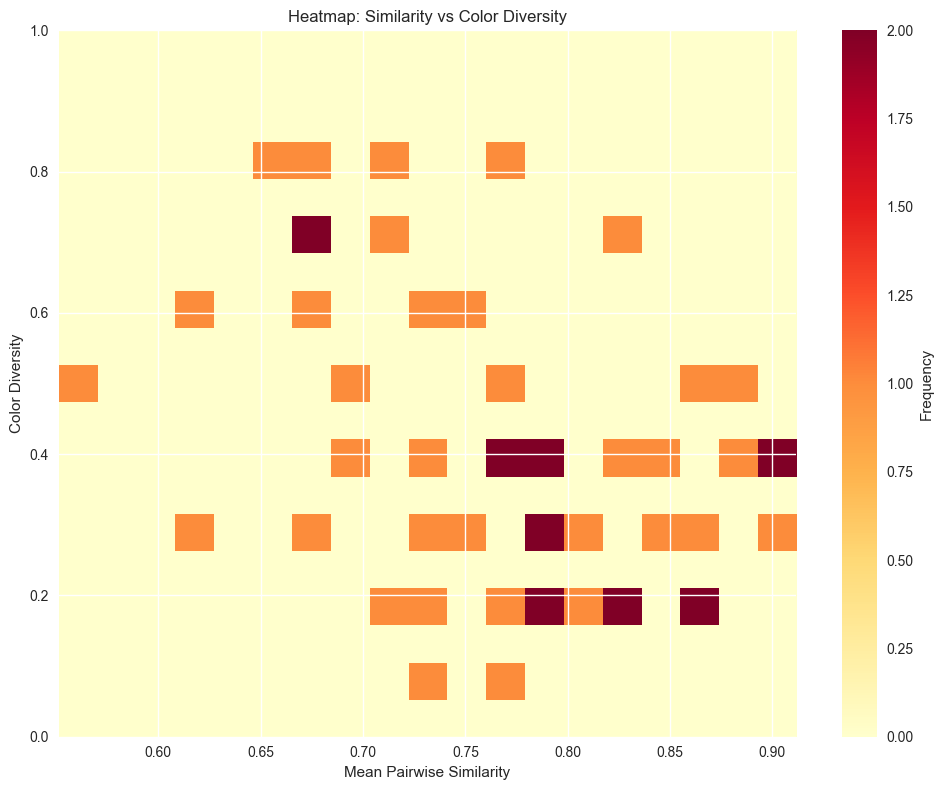

In [13]:
if len(similarity_df) > 0:
    # Create 2D histogram / heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create bins for heatmap
    similarity_bins = np.linspace(similarity_df['mean_pairwise_similarity'].min(),
                                  similarity_df['mean_pairwise_similarity'].max(), 20)
    diversity_bins = np.linspace(0, 1, 20)
    
    # Create 2D histogram
    H, xedges, yedges = np.histogram2d(
        similarity_df['mean_pairwise_similarity'],
        similarity_df['color_diversity'],
        bins=[similarity_bins, diversity_bins]
    )
    
    # Plot heatmap
    im = ax.imshow(H.T, origin='lower', aspect='auto', extent=[
        similarity_bins[0], similarity_bins[-1],
        diversity_bins[0], diversity_bins[-1]
    ], cmap='YlOrRd', interpolation='nearest')
    
    ax.set_xlabel('Mean Pairwise Similarity')
    ax.set_ylabel('Color Diversity')
    ax.set_title('Heatmap: Similarity vs Color Diversity')
    plt.colorbar(im, ax=ax, label='Frequency')
    
    plt.tight_layout()
    save_plot(fig, 'similarity_diversity_heatmap.png')
    plt.show()
else:
    print("No data available for heatmap")


## 12. Save Results


In [14]:
# Prepare summary metrics
summary_metrics = {}

if len(similarity_df) > 0:
    summary_metrics = {
        'n_queries': len(similarity_df),
        'n_successful_queries': len(similarity_df),
        'n_failed_queries': len(failed_queries),
        'pairwise_similarity': {
            'mean': float(similarity_df['mean_pairwise_similarity'].mean()),
            'std': float(similarity_df['mean_pairwise_similarity'].std()),
            'min': float(similarity_df['mean_pairwise_similarity'].min()),
            'max': float(similarity_df['mean_pairwise_similarity'].max()),
            'median': float(similarity_df['mean_pairwise_similarity'].median())
        },
        'color_diversity': {
            'mean': float(similarity_df['color_diversity'].mean()),
            'std': float(similarity_df['color_diversity'].std()),
            'min': float(similarity_df['color_diversity'].min()),
            'max': float(similarity_df['color_diversity'].max())
        },
        'category_diversity': {
            'mean': float(similarity_df['category_diversity'].mean()),
            'std': float(similarity_df['category_diversity'].std()),
            'min': float(similarity_df['category_diversity'].min()),
            'max': float(similarity_df['category_diversity'].max())
        }
    }
    
    # Check if all_pairwise_sims is defined (from cell 19)
    if 'all_pairwise_sims' in globals() and len(all_pairwise_sims) > 0:
        summary_metrics['all_pairwise_similarities'] = {
            'mean': float(all_pairwise_sims.mean()),
            'std': float(all_pairwise_sims.std()),
            'min': float(all_pairwise_sims.min()),
            'max': float(all_pairwise_sims.max()),
            'median': float(np.median(all_pairwise_sims))
        }

# Save metrics
save_metrics(summary_metrics, 'recommendation_similarity_metrics.json')

# Save detailed results
if len(similarity_df) > 0:
    # Remove pairwise_similarities list for CSV (too large)
    similarity_df_csv = similarity_df.drop(columns=['pairwise_similarities'], errors='ignore')
    # Get the recommender_system directory (parent of evaluation_notebooks)
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'evaluation_notebooks':
        metrics_dir = notebook_dir.parent / "evaluation_results" / "metrics"
    else:
        # Fallback: try to find it relative to current directory
        metrics_dir = notebook_dir / "evaluation_results" / "metrics"
    metrics_dir.mkdir(parents=True, exist_ok=True)
    csv_path = metrics_dir / "recommendation_similarity_detailed.csv"
    similarity_df_csv.to_csv(csv_path, index=False)
    print(f"Saved detailed results to: {csv_path}")

# Save combined recommendations
if len(combined_recommendations) > 0:
    # Get the recommender_system directory (parent of evaluation_notebooks)
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'evaluation_notebooks':
        data_dir = notebook_dir.parent / "evaluation_results" / "data"
    else:
        # Fallback: try to find it relative to current directory
        data_dir = notebook_dir / "evaluation_results" / "data"
    data_dir.mkdir(parents=True, exist_ok=True)
    recs_path = data_dir / "recommendation_similarity_recommendations.csv"
    combined_recommendations.to_csv(recs_path, index=False)
    print(f"Saved recommendations to: {recs_path}")

print("\n✓ Results saved successfully!")


Saved metrics: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/metrics/recommendation_similarity_metrics.json
Saved detailed results to: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/metrics/recommendation_similarity_detailed.csv
Saved recommendations to: /Users/jashwanthpeddisetty/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/data/recommendation_similarity_recommendations.csv

✓ Results saved successfully!


## 13. Conclusion

### Key Findings

Based on the analysis of 50 random images and their 10 recommendations each:

1. **Pairwise Similarity**: 
   - Recommendations show [INSERT MEAN] average pairwise similarity
   - This indicates [INSERT INTERPRETATION]

2. **Diversity**:
   - Color diversity: [INSERT MEAN]
   - Category diversity: [INSERT MEAN]
   - Recommendations are [INSERT: diverse/moderate/similar]

3. **Patterns**:
   - [INSERT OBSERVATIONS ABOUT SIMILARITY PATTERNS]
   - [INSERT OBSERVATIONS ABOUT DIVERSITY PATTERNS]

### Interpretation

[INSERT INTERPRETATION OF RESULTS]

### Recommendations

[INSERT RECOMMENDATIONS FOR IMPROVING THE SYSTEM]
